# Model comparison: revised pipeline vs. Sugiyama et al. 2023

**Purpose.** Evaluate the revised likelihood (`scripts/hsc_lens.py`) at the *published* MAP
parameters and compare, probe by probe, against the literature best-fit theory vector and the
published $\ln\mathcal{L}$. This is the Phase-1 validation gate: all three fixes (PSF term,
pair-weighted $\langle\Sigma_{\rm cr}^{-1}\rangle$, linear Kaiser ratio) should close the
discrepancies seen in the earlier `mine/literature` ratio plot.

**Prerequisites** (paths relative to repo root):
- `data/dataset_hsc_y3.fits` — with the **corrected** lens n(z) (CMASS bins at their true z)
- `data/dataset/psf_pp_pq_qq_used.dat`, `sumwlssigcritinvPz_z[0-2].dat`, `photoz_bin.dat`
- `data/chain_equal_weights.dat` + `data/param_names.dat` (published chain)
- optional: `data/lit_bestfit_signal.txt` (released best-fit theory vector, masked, length 74)

**Pass criteria**
1. every point of `mine/lit` within the ±1% band (shaded) — or within 0.1σ pulls;
2. $\chi^2$ at the published MAP within ~0.5 of $-2\ln\mathcal{L}$ from the chain.

In [61]:
import os, sys, copy
import numpy as np
import matplotlib.pyplot as plt
import yaml

REPO = os.path.abspath('..')          # notebook lives in notebooks/
sys.path.insert(0, os.path.join(REPO, 'scripts'))
sys.path.insert(0, os.path.join(REPO, 'theory'))

DATA = os.path.join(REPO, 'fiducial')
CHAIN_FILE  = os.path.join(DATA, 'chain_equal_weights.dat')
PNAMES_FILE = os.path.join(DATA, 'param_names.dat')
LIT_SIGNAL  = '/home/weichen/cosmo_practice/lit_bestfit_signal.txt'

plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})

## 1. Build the likelihood through cobaya

We instantiate via `get_model` on the ΛCDM config so priors/params match exactly what an MCMC
would use, then grab the likelihood object to access its internals
(`_build_cosmology`, `theory_vector`, masks, covariance).

In [62]:
from cobaya.model import get_model

with open('/home/weichen/cosmo_practice/test_cobaya/configs/lcdm_hsc_only.yaml') as f:
    info = yaml.safe_load(f)
info.pop('output', None)
info.pop('sampler', None)
info['likelihood']['hsc_lens.HSC_Lens']['python_path'] = os.path.join(REPO, 'scripts')
info['likelihood']['hsc_lens.HSC_Lens']['data_folder'] = DATA

info['likelihood']['hsc_lens.HSC_Lens'].update({
    'xip_tmin': 7.943282347242816,
    'xip_tmax': 50.11872336272722,
    'xim_tmin': 31.622776601683793,
    'xim_tmax': 158.48931924611142,
})

model = get_model(info)
like = list(model.likelihood.values())[0]
print('data vector length:', len(like.data_vector))
print('blocks: ds=%d xip=%d xim=%d wp=%d' % (like.ds_cut.sum(), like.xip_cut.sum(),
                                             like.xim_cut.sum(), like.wp_cut.sum()))

[hsc_lens.hsc_lens] Loading dataset: /home/weichen/cosmo_practice/test_cobaya/fiducial/dataset_hsc_y3.fits
[hsc_lens.hsc_lens] *WARNING* nz_lens BIN2 peaks at z<=0.35; expected ~[0.42,0.56]. Rebuild the FITS from nzl_z1_100bin.dat!
[hsc_lens.hsc_lens] *WARNING* nz_lens BIN3 peaks at z<=0.35; expected ~[0.54,0.71]. Rebuild the FITS from nzl_z2_100bin.dat!
[hsc_lens.hsc_lens] data vector: ds=17 xip=8 xim=7 wp=42 total=74 (Hartlap 0.9460, Nsim=1391)
[hsc_lens.hsc_lens] Using pair-weighted sumwlssigcritinvPz correction.
data vector length: 74
blocks: ds=17 xip=8 xim=7 wp=42


## 2. Published MAP point

Load the equal-weight chain and its parameter names, take the maximum-posterior row, and map
their names onto ours. **Edit `NAME_MAP` after inspecting the printed names** — cosmology
naming in `param_names.dat` must be verified once by eye (the nuisance names below were
confirmed earlier from the released chain).

In [63]:
# pnames = [l.strip() for l in open(PNAMES_FILE) if l.strip()]

# rows = [list(map(float, l.split())) for l in open(CHAIN_FILE)
#         if len(l.split()) == 96]
# chain = np.array(rows)
# print(chain.shape)

# print('chain shape:', chain.shape, ' n_names:', len(pnames))
# for i, n in enumerate(pnames):
#     print(f'{i:3d}  {n}')

In [64]:
import numpy as np

P = {}
for line in open('/home/weichen/cosmo_practice/lit_bestfit_params.txt'):
    if '=' in line:
        k, v = line.split('=')
        P[k.strip()] = float(v)

sig = np.loadtxt('/home/weichen/cosmo_practice/lit_bestfit_signal.txt')
print('len(sig) =', len(sig), '  len(data) =', len(like.data_vector))

# 先驗證 sig 是對的
d = like.data_vector - sig
print('chi2(lit theory vs data) =', d @ like.inv_cov @ d, '  (應 ~70)')

len(sig) = 74   len(data) = 74
chi2(lit theory vs data) = 70.53855162349919   (應 ~70)


In [81]:
d = np.loadtxt('/home/weichen/cosmo_practice/test_cobaya/fiducial/dataset/nzl_z1_100bin.dat')
print(d.shape)
print(d[:5])
print('z range:', d[:,0].min(), '-', d[:,0].max())

(100, 2)
[[  0.43060685 106.        ]
 [  0.43180678 106.        ]
 [  0.4330067  123.        ]
 [  0.43420662 131.        ]
 [  0.43540654 142.        ]]
z range: 0.43060685291883505 - 0.549399216026165


In [84]:
DD = '/home/weichen/cosmo_practice/test_cobaya/fiducial/dataset'
nzl = [np.loadtxt(f'{DD}/nzl_z{i}_100bin.dat') for i in range(3)]

for i, d in enumerate(nzl):
    print(f'z{i}: {d[:,0].min():.4f} – {d[:,0].max():.4f}')

# 共同網格,涵蓋三個 bin
z_common = np.linspace(0.10, 0.75, 400)
nz_new = []
for d in nzl:
    n = np.interp(z_common, d[:, 0], d[:, 1], left=0.0, right=0.0)
    n = n / np.trapezoid(n, z_common)          # 正規化
    nz_new.append(n)

like.z_lg = z_common
like.nz_l = nz_new

for i in range(3):
    print(f'BIN{i+1}: mean z = {np.average(z_common, weights=nz_new[i]):.4f}')

z0: 0.1510 – 0.3490
z1: 0.4306 – 0.5494
z2: 0.5508 – 0.6992
BIN1: mean z = 0.2692
BIN2: mean z = 0.5048
BIN3: mean z = 0.6301


In [85]:
map_params = {
    'ombh2': P['Ombh2'],
    'omch2': P['Omch2'],
    'H0':    100 * P['h_derived'],
    'ns':    P['ns'],
    'logA':  P['ln10p10As'],
    'b1': P['b1_0'], 'b2': P['b1_1'], 'b3': P['b1_2'],
    'AIA':   P['AIA'],
    'dm_0':  P['dm_0'],
    'dpz_0': P['dpz_0'],
    # 舊版沒有,用 analysis_config.yaml 的 prior 中心值
    'alphapsf':   -0.026388403398119948,
    'betapsf':    -1.65586223022114,
    'alphamag_1':  2.26,
    'alphamag_2':  3.56,
    'alphamag_3':  3.73,
}
for k, v in map_params.items():
    print(f'{k:12s} = {v:+.6f}')

lit_lnpost = P['lnpost']
for k, v in map_params.items():
    print(f'{k:12s} = {v:+.6f}')

ombh2        = +0.022673
omch2        = +0.104577
H0           = +56.850700
ns           = +0.959513
logA         = +3.030242
b1           = +2.184773
b2           = +2.662382
b3           = +2.795967
AIA          = +3.172051
dm_0         = -0.002432
dpz_0        = -0.030939
alphapsf     = -0.026388
betapsf      = -1.655862
alphamag_1   = +2.260000
alphamag_2   = +3.560000
alphamag_3   = +3.730000
ombh2        = +0.022673
omch2        = +0.104577
H0           = +56.850700
ns           = +0.959513
logA         = +3.030242
b1           = +2.184773
b2           = +2.662382
b3           = +2.795967
AIA          = +3.172051
dm_0         = -0.002432
dpz_0        = -0.030939
alphapsf     = -0.026388
betapsf      = -1.655862
alphamag_1   = +2.260000
alphamag_2   = +3.560000
alphamag_3   = +3.730000


In [66]:
# imap = int(np.argmax(chain[:, -1]))

# Omde = chain[imap, 2]
# omm  = 1.0 - Omde
# h    = np.sqrt((chain[imap,0] + chain[imap,1] + 0.06/93.14) / omm)

# map_params = {
#     'logA':  chain[imap, 3],
#     'ombh2': chain[imap, 0],
#     'omch2': chain[imap, 1],
#     'H0':    100*h,
#     'ns':    chain[imap, 4],
#     'b1': chain[imap,5], 'b2': chain[imap,6], 'b3': chain[imap,7],
#     'AIA':   chain[imap,13],
#     'dm_0':  chain[imap,11],
#     'dpz_0': chain[imap,12],
#     'alphapsf': chain[imap,14],
#     'betapsf':  chain[imap,15],
#     'alphamag_1': chain[imap,8],
#     'alphamag_2': chain[imap,9],
#     'alphamag_3': chain[imap,10],
# }
# for k, v in map_params.items():
#     print(f'{k:12s} = {v:+.6f}')

In [86]:
print('ds =', like.ds_cut.sum(),
      ' xip =', like.xip_cut.sum(),
      ' xim =', like.xim_cut.sum(),
      ' wp =', like.wp_cut.sum())
print(like.xim_t['ANG'][like.xim_cut])

ds = 17  xip = 8  xim = 7  wp = 42
[ 35.98772377  45.8599026   58.44022479  74.4715902   94.90069156
 120.93391901 154.10860056]


In [68]:
# # ---- EDIT AFTER INSPECTING THE PRINTOUT ABOVE ----------------------------
# # our param  ->  candidate names in param_names.dat (first match wins)
# NAME_MAP = {
#     'logA':      ['ln10p10As', 'lnAs', 'ln10^{10}As', 'logAs'],
#     'ombh2':     ['omega_b', 'ombh2', 'Omega_b_h2'],
#     'omch2':     ['omega_c', 'omch2', 'Omega_c_h2'],
#     'H0':        ['H0', 'h0'],
#     'ns':        ['ns', 'n_s'],
#     'b1':        ['b1_0', 'b1z0', 'b1_L0'],
#     'b2':        ['b1_1', 'b1z1', 'b1_L1'],
#     'b3':        ['b1_2', 'b1z2', 'b1_L2'],
#     'AIA':       ['AIA', 'A_IA'],
#     'dm_0':      ['dm_0', 'dm'],
#     'dpz_0':     ['dpz_0', 'dpz'],
#     'alphapsf':  ['alphapsf'],
#     'betapsf':   ['betapsf'],
#     'alphamag_1':['alphamag_0'],
#     'alphamag_2':['alphamag_1'],
#     'alphamag_3':['alphamag_2'],
# }
# # column with the posterior/likelihood (check header/README of the chain!)
# LNP_CANDIDATES = ['lnpost', 'lnlike', 'lnP', 'loglike', 'weight']

# def find_col(cands):
#     for c in cands:
#         if c in pnames:
#             return pnames.index(c)
#     return None

# lnp_col = find_col(LNP_CANDIDATES)
# if lnp_col is None:
#     print('!! no lnpost/lnlike column found by name; assuming LAST column is lnlike')
#     lnp_col = chain.shape[1] - 1
# imap = int(np.argmax(chain[:, lnp_col]))
# print('MAP row:', imap, ' lnP =', chain[imap, lnp_col])

# map_params = {}
# for ours, cands in NAME_MAP.items():
#     col = find_col(cands)
#     if col is None:
#         raise KeyError(f'no column found for {ours}: tried {cands} -- edit NAME_MAP')
#     map_params[ours] = float(chain[imap, col])
# map_params

## 3. Evaluate our model at the MAP

`model.logposterior` fills derived params and returns the log-likelihood; we also pull the
theory vector directly. Then re-evaluate with each fix disabled to attribute residuals.

In [87]:
def theory_at(params, *, psf=True, pairweight=True, kaiser=True):
    """Theory vector at `params` with individual fixes toggled."""
    import hsc_lens as HL
    like_ = like
    # toggle PSF
    psf_save = like_.psf
    if not psf: like_.psf = np.zeros_like(psf_save)
    # toggle pair-weighted Sigma_cr correction
    mc_save = like_.meascorr
    if not pairweight: like_.meascorr = None
    # toggle Kaiser (patch the ratio to unity)
    kr_save = HL._kaiser_ratio
    if not kaiser:
        HL._kaiser_ratio = lambda r, xi, beta, pimax: (lambda rp: np.ones_like(np.atleast_1d(rp)))
    try:
        pv = dict(params)
        pv['As'] = 1e-10 * np.exp(pv.pop('logA'))
        base, cosmo, gr, om = like_._build_cosmology(pv)
        vec = like_.theory_vector(base, cosmo, gr, om, pv)
    finally:
        like_.psf = psf_save
        like_.meascorr = mc_save
        HL._kaiser_ratio = kr_save
    return vec

vec_full     = theory_at(map_params)
vec_nopsf    = theory_at(map_params, psf=False)
vec_stacked  = theory_at(map_params, pairweight=False)
vec_nokaiser = theory_at(map_params, kaiser=False)

d = like.data_vector - vec_full
chi2 = float(d @ like.inv_cov @ d)
print(f'chi2(full model at published MAP) = {chi2:.2f}   (N_data = {len(d)})')
print(f'published -2 lnpost at MAP        = {-2*lit_lnpost:.2f}')

chi2(full model at published MAP) = 71.80   (N_data = 74)
published -2 lnpost at MAP        = 95.00


## 4. Ratio to the literature best-fit vector

If the released best-fit theory vector is available, reproduce the diagnostic ratio plot —
now with the before/after variants overlaid, so each fix is visibly responsible for closing
its block. (If the file is absent, skip to the pulls plot in §5, which needs only the data.)

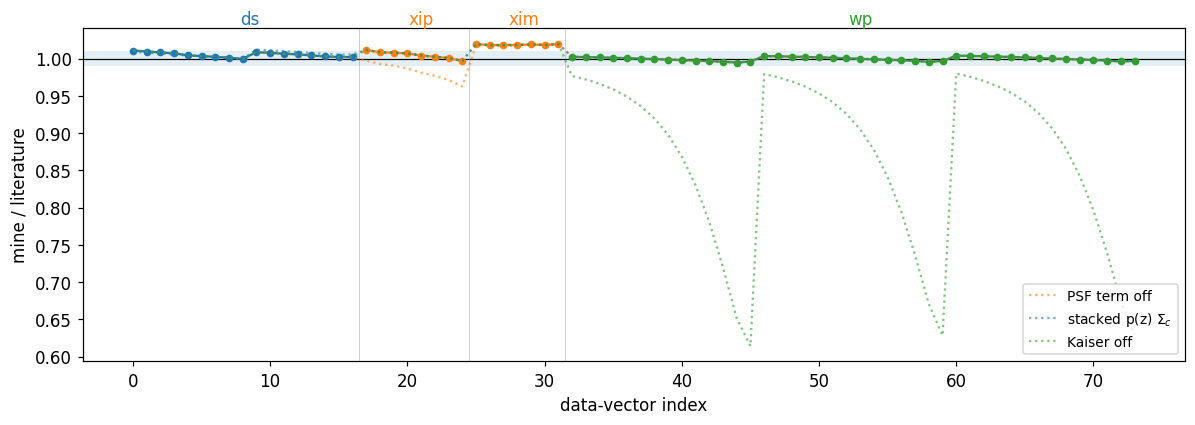

In [88]:
blocks = [('ds', like.ds_cut.sum(), 'C0'), ('xip', like.xip_cut.sum(), 'C1'),
          ('xim', like.xim_cut.sum(), 'C1'), ('wp', like.wp_cut.sum(), 'C2')]
edges = np.cumsum([0] + [n for _, n, _ in blocks])

if os.path.exists(LIT_SIGNAL):
    lit = np.loadtxt(LIT_SIGNAL)
    assert lit.size == len(vec_full), f'lit vector {lit.size} vs ours {len(vec_full)}'

    fig, ax = plt.subplots(figsize=(11, 4))
    ax.axhspan(0.99, 1.01, color='C0', alpha=0.12, lw=0)
    ax.axhline(1.0, color='k', lw=0.8)
    x = np.arange(len(vec_full))
    for (name, n, c), lo, hi in zip(blocks, edges[:-1], edges[1:]):
        ax.plot(x[lo:hi], (vec_full/lit)[lo:hi], 'o-', ms=4, color=c, label=None)
    # dashed: fixes disabled (should reproduce the OLD discrepancies)
    ax.plot(x, vec_nopsf/lit,    ':', color='C1', alpha=.6, label='PSF term off')
    ax.plot(x, vec_stacked/lit,  ':', color='C0', alpha=.6, label=r'stacked p(z) $\Sigma_c$')
    ax.plot(x, vec_nokaiser/lit, ':', color='C2', alpha=.6, label='Kaiser off')
    for e in edges[1:-1]:
        ax.axvline(e-.5, color='gray', lw=.5, alpha=.5)
    for (name, n, c), lo in zip(blocks, edges[:-1]):
        ax.text(lo + n/2, ax.get_ylim()[1], name, ha='center', va='bottom', color=c)
    ax.set_xlabel('data-vector index'); ax.set_ylabel('mine / literature')
    ax.legend(loc='lower right', fontsize=9); plt.tight_layout(); plt.show()
else:
    print('lit_bestfit_signal.txt not found -- skipping; use the pulls plot below.')

## 5. Pulls against the data

Independent of any released theory vector: residuals of our MAP prediction against the *data*
in units of the diagonal errors. At the true MAP these should scatter like the published fit
does (reduced $\chi^2 \approx$ theirs), with **no coherent per-block offset**.

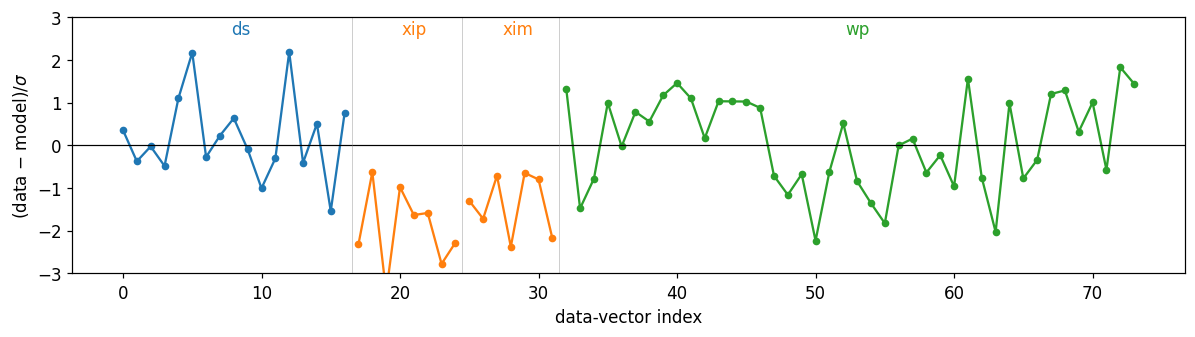

ds  : mean pull = +0.200, chi2/n = 0.96
xip : mean pull = -1.960, chi2/n = 4.61
xim : mean pull = -1.394, chi2/n = 2.38
wp  : mean pull = +0.089, chi2/n = 1.17


In [92]:
sig = 1/np.sqrt(np.diag(like.inv_cov))   # note: includes Hartlap; fine for pulls
pull = (like.data_vector - vec_full) / sig

fig, ax = plt.subplots(figsize=(11, 3.2))
x = np.arange(len(pull))
for (name, n, c), lo, hi in zip(blocks, edges[:-1], edges[1:]):
    ax.plot(x[lo:hi], pull[lo:hi], 'o-', ms=4, color=c)
    ax.text(lo + n/2, 2.6, name, ha='center', color=c)
ax.axhline(0, color='k', lw=.8); ax.set_ylim(-3, 3)
for e in edges[1:-1]: ax.axvline(e-.5, color='gray', lw=.5, alpha=.5)
ax.set_xlabel('data-vector index'); ax.set_ylabel(r'(data $-$ model)/$\sigma$')
plt.tight_layout(); plt.show()

for (name, n, c), lo, hi in zip(blocks, edges[:-1], edges[1:]):
    print(f'{name:4s}: mean pull = {pull[lo:hi].mean():+.3f}, chi2/n = '
          f'{np.sum(pull[lo:hi]**2)/n:.2f}')

In [94]:
pull_lit = (like.data_vector - lit) / (1/np.sqrt(np.diag(like.inv_cov)))
n1, n2, n3 = like.ds_cut.sum(), like.xip_cut.sum(), like.xim_cut.sum()
for name, s in [('ds', slice(0,n1)), ('xip', slice(n1,n1+n2)),
                ('xim', slice(n1+n2,n1+n2+n3)), ('wp', slice(n1+n2+n3,None))]:
    p = pull_lit[s]
    print(f'{name:4s} lit: mean pull = {p.mean():+.3f}, chi2/n = {np.sum(p**2)/len(p):.2f}')

ds   lit: mean pull = +0.236, chi2/n = 0.96
xip  lit: mean pull = -1.826, chi2/n = 4.14
xim  lit: mean pull = -1.147, chi2/n = 1.77
wp   lit: mean pull = +0.103, chi2/n = 1.15


## 6. Attribution table

$\Delta\chi^2$ contribution of each fix, evaluated at the published MAP. Large positive
numbers = removing the fix badly degrades the fit = the fix matters.

In [93]:
def chi2_of(vec):
    r = like.data_vector - vec
    return float(r @ like.inv_cov @ r)

rows = [('full model (all fixes)', vec_full),
        ('PSF term disabled',      vec_nopsf),
        ('stacked-p(z) Sigma_cr',  vec_stacked),
        ('Kaiser ratio disabled',  vec_nokaiser)]
print(f'{"variant":28s} {"chi2":>9s} {"dchi2 vs full":>14s}')
c0 = chi2_of(vec_full)
for name, v in rows:
    c = chi2_of(v)
    print(f'{name:28s} {c:9.2f} {c-c0:14.2f}')

variant                           chi2  dchi2 vs full
full model (all fixes)           71.80           0.00
PSF term disabled                71.83           0.04
stacked-p(z) Sigma_cr            71.78          -0.01
Kaiser ratio disabled            81.52           9.72


## 7. Troubleshooting map

| symptom (which block off) | first thing to check |
|---|---|
| $\xi_+$ low, worsening with $\theta$; $\xi_-$ fine | PSF file/columns (pp+, pp−, pq+, pq−, qq+, qq−); term added *after* $(1+\Delta m)^2$ |
| $\Delta\Sigma$ per-bin steps growing with lens $z$ | `sumwlssigcritinvPz` loading; sign of $z_s - \Delta z$; `photoz_bin.dat` grid |
| $w_p$ droop growing with $R$ | Kaiser ratio built from **linear** $\xi$; $\beta=f/b$; $\Pi_{\rm max}/E_{\rm fac}$ |
| overall few-% amplitude everywhere | $A_s$ vs $\sigma_8$ handling; $m_\nu$ in CCL; halofit flavor vs `analysis_config.yaml` |
| sub-% sawtooth within bins | bin-averaging (`binave`, $R\,dR$ weight) vs bin-center evaluation |
| $\chi^2$ off by O(1) with perfect vectors | Hartlap $N_{\rm sim}=1404$; mask/cut ordering vs published covariance |

When every point sits inside ±1% and the MAP $\chi^2$ matches, tag the commit
(`v0-lcdm-reproduction`) and record the numbers in the Phase-1 note.